In [11]:
# PACKAGE INSTALLATION

!pip3 install scikit-learn pandas matplotlib seaborn

In [1]:
# IMPORTS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score, 
        confusion_matrix, roc_curve, auc, classification_report
    )
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline


In [2]:
# DATA LOADING

# load built-in UCI Breast Cancer Wisconsin (Diagnostic) dataset
data = load_breast_cancer()

# feature matrix and label vector
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("X shape:", X.shape) # expected (569, 30)
print("y shape:", y.shape) # expected (569,)
print("target names:", data.target_names)
X.head()

X shape: (569, 30)
y shape: (569,)
target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Class Distribution:
 target
1    357
0    212
Name: count, dtype: int64


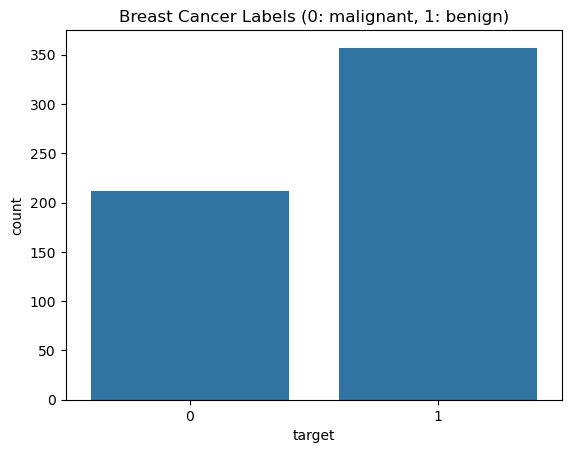

In [3]:
# EXPLORATORY DATA ANALYSIS

# confirm class balance
print("Class Distribution:\n", y.value_counts())

# plot counts visually
sns.countplot(x=y)
plt.title("Breast Cancer Labels (0: malignant, 1: benign)")
plt.show()

In [4]:
# DATA PREPROCESSING

# stratified split preserves class ratio in train/test
# splitting into 80% training and 20% for testing
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# standardize features (mean=0, std=1)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("x_train:", x_train.shape, "x_test:", x_test.shape)

x_train: (455, 30) x_test: (114, 30)


Baseline (all features) accuracy: 0.9824561403508771
PCA n_components= 2, acc=0.9474, var_pct=0.6336
PCA n_components= 4, acc=0.9649, var_pct=0.7963
PCA n_components= 6, acc=0.9561, var_pct=0.8908
PCA n_components= 8, acc=0.9649, var_pct=0.9284
PCA n_components=10, acc=0.9737, var_pct=0.9527
PCA n_components=15, acc=0.9825, var_pct=0.9868
PCA n_components=20, acc=0.9825, var_pct=0.9958
SelectKBest k= 2, acc=0.9561
SelectKBest k= 4, acc=0.9298
SelectKBest k= 6, acc=0.9298
SelectKBest k= 8, acc=0.9474
SelectKBest k=10, acc=0.9561
SelectKBest k=15, acc=0.9474
SelectKBest k=20, acc=0.9825
SelectKBest k=25, acc=0.9825
SelectKBest k=30, acc=0.9825

Best PCA: (15, 0.9824561403508771, np.float64(0.9868409065192458))
Best SelectKBest: (20, 0.9824561403508771)


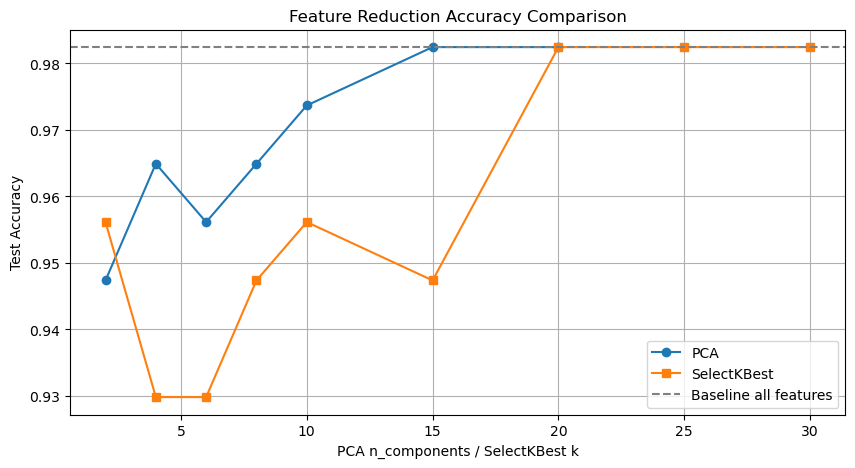

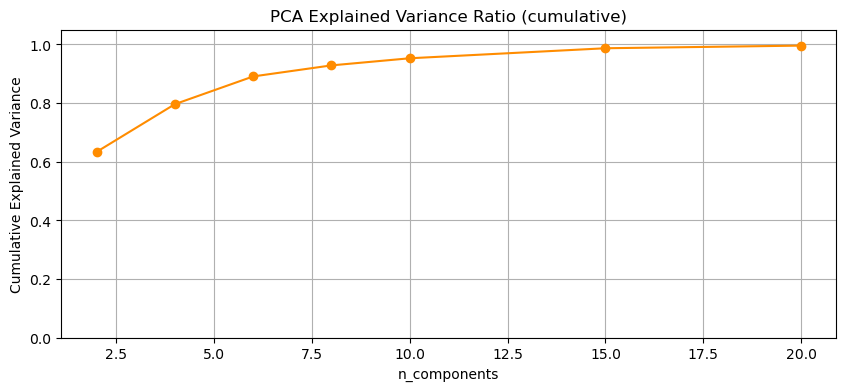

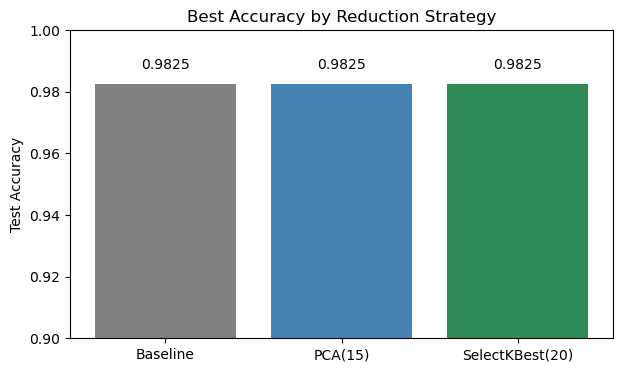

In [5]:
# (PATH 1) FEATURE REDUCTION AND MODELING

# baseline
model_base = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_base.fit(x_train, y_train)
acc_base = accuracy_score(y_test, model_base.predict(x_test))

print("Baseline (all features) accuracy:", acc_base)

# PCA sweep
pca_values = [2, 4, 6, 8, 10, 15, 20]  # adjust
pca_results = []
for n in pca_values:
    pca = PCA(n_components=n, random_state=42)
    xt = pca.fit_transform(x_train)
    xv = pca.transform(x_test)
    m = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42).fit(xt, y_train)
    acc = accuracy_score(y_test, m.predict(xv))
    pca_results.append((n, acc, np.sum(pca.explained_variance_ratio_)))
    print(f"PCA n_components={n:2d}, acc={acc:.4f}, var_pct={pca_results[-1][2]:.4f}")

# SelectKBest sweep
k_values = [2, 4, 6, 8, 10, 15, 20, 25, 30]
kbest_results = []
for k in k_values:
    sel = SelectKBest(score_func=f_classif, k=k)
    xt = sel.fit_transform(x_train, y_train)
    xv = sel.transform(x_test)
    m = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42).fit(xt, y_train)
    acc = accuracy_score(y_test, m.predict(xv))
    kbest_results.append((k, acc))
    print(f"SelectKBest k={k:2d}, acc={acc:.4f}")

# summary
best_pca = max(pca_results, key=lambda t: t[1])
best_kbest = max(kbest_results, key=lambda t: t[1])
print("\nBest PCA:", best_pca)
print("Best SelectKBest:", best_kbest)

# Prepare plotting arrays
pca_ns = [n for n, _, _ in pca_results]
pca_accs = [acc for _, acc, _ in pca_results]
pca_vars = [var for _, _, var in pca_results]

k_sel = [k for k, _ in kbest_results]
k_accs = [acc for _, acc in kbest_results]

# accuracy vs components/k
plt.figure(figsize=(10, 5))
plt.plot(pca_ns, pca_accs, marker='o', label='PCA')
plt.plot(k_sel, k_accs, marker='s', label='SelectKBest')
plt.axhline(acc_base, color='gray', linestyle='--', label='Baseline all features')
plt.title('Feature Reduction Accuracy Comparison')
plt.xlabel('PCA n_components / SelectKBest k')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# PCA explained variance as additional context
plt.figure(figsize=(10, 4))
plt.plot(pca_ns, pca_vars, marker='o', color='darkorange')
plt.title('PCA Explained Variance Ratio (cumulative)')
plt.xlabel('n_components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

labels = ['Baseline', f'PCA({best_pca[0]})', f'SelectKBest({best_kbest[0]})']
vals = [acc_base, best_pca[1], best_kbest[1]]
plt.figure(figsize=(7,4))
plt.bar(labels, vals, color=['gray','steelblue','seagreen'])
plt.ylim(0.90, 1.0)  # scaled range
plt.title('Best Accuracy by Reduction Strategy')
plt.ylabel('Test Accuracy')
for i,v in enumerate(vals):
    plt.text(i, v+0.005, f"{v:.4f}", ha='center')
plt.show()

In [6]:
# (PATH 1) CROSS-VALIDATION PIPELINE FOR PCA AND SELECTKBEST

def cv_mean(std):
    return np.mean(std), np.std(std)

for n in pca_values:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('pca', PCA(n_components=n, random_state=42)),
                     ('svc', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    print(f"PCA {n}, CV mean {scores.mean():.4f}, std {scores.std():.4f}")

for k in k_values:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('kbest', SelectKBest(f_classif, k=k)),
                     ('svc', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    print(f"SelectKBest {k}, CV mean {scores.mean():.4f}, std {scores.std():.4f}")

PCA 2, CV mean 0.9403, std 0.0202
PCA 4, CV mean 0.9578, std 0.0151
PCA 6, CV mean 0.9684, std 0.0119
PCA 8, CV mean 0.9701, std 0.0142
PCA 10, CV mean 0.9772, std 0.0089
PCA 15, CV mean 0.9754, std 0.0129
PCA 20, CV mean 0.9754, std 0.0129
SelectKBest 2, CV mean 0.9350, std 0.0070
SelectKBest 4, CV mean 0.9490, std 0.0187
SelectKBest 6, CV mean 0.9455, std 0.0217
SelectKBest 8, CV mean 0.9455, std 0.0244
SelectKBest 10, CV mean 0.9420, std 0.0275
SelectKBest 15, CV mean 0.9350, std 0.0196
SelectKBest 20, CV mean 0.9754, std 0.0151
SelectKBest 25, CV mean 0.9754, std 0.0140
SelectKBest 30, CV mean 0.9736, std 0.0147


In [7]:
# (PATH 2) MODEL TRAINING

# RBF SVM with default regularization parameters
model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# training
model.fit(x_train, y_train)

# debug: check training accuracy
print("training complete")

training complete


In [8]:
# (PATH 2a) SIMPLE EVALUATION

# predict on test set
preds = model.predict(x_test)

# report accuracy, confusion matrix, classification report
print("Accuracy:", accuracy_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
print("Classification Report:\n", classification_report(y_test, preds))

Accuracy: 0.9824561403508771
Confusion Matrix:
 [[41  1]
 [ 1 71]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Metrics
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112


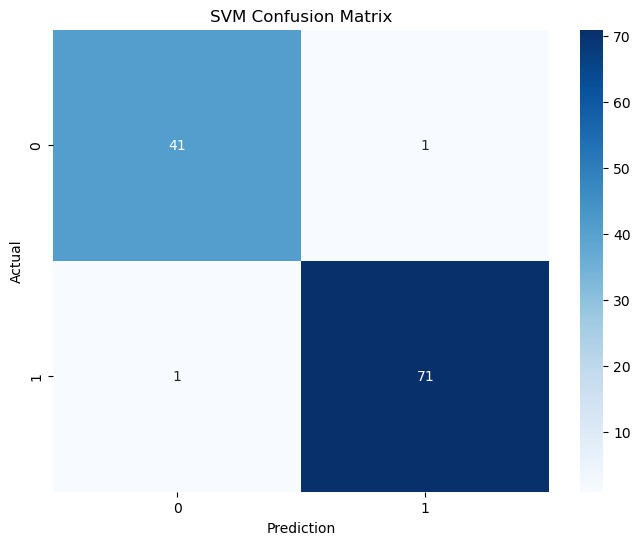

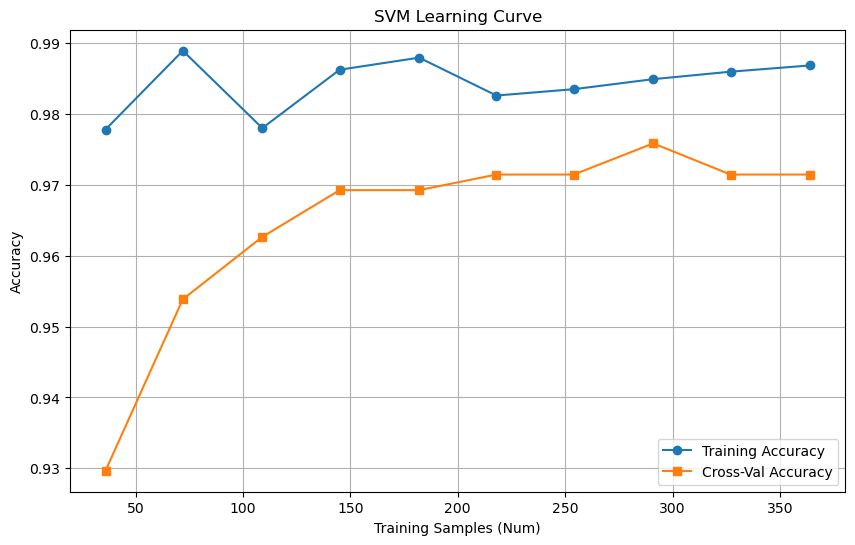


AUC Score: 0.9950


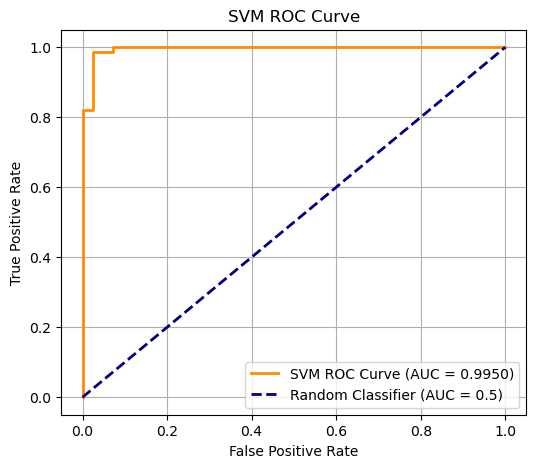

In [12]:
# (PATH 2a) VISUALIZATION

y_pred = model.predict(x_test)
    
print("Metrics")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# confusion matrix heatmap
plt.figure(figsize= (8,6))
sns.heatmap(confusion_matrix(y_test, preds), annot = True, fmt = 'd', cmap = 'Blues')

# labels and title
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

# grid and show
plt.show()

#computing learning curve
train_size, train_score, test_score = learning_curve(model,  x_train, y_train, cv = 5, scoring = 'accuracy', train_sizes = np.linspace(.10, 1.0, 10))

#means and std
train_m = np.mean(train_score, axis = 1)
test_m = np.mean(test_score, axis = 1)

# plotting learning curve
plt.figure(figsize = (10,6))
plt.plot(train_size, train_m, label = 'Training Accuracy', marker ='o')
plt.plot(train_size, test_m, label = 'Cross-Val Accuracy', marker ='s')
plt.xlabel("Training Samples (Num)")
plt.ylabel("Accuracy")
plt.title("SVM Learning Curve")

# grid and legend
plt.grid(True)
plt.legend()

# show plot
plt.show()

y_score = model.decision_function(x_test)
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
print(f"\nAUC Score: {roc_auc:.4f}")
plt.figure(figsize=(6,5))

# SVM ROC curve
plt.plot(
    fpr, tpr,
    color='darkorange',
    lw=2,
    label=f'SVM ROC Curve (AUC = {roc_auc:.4f})'
)

# random classifier baseline
plt.plot(
    [0,1], [0,1],
    color='navy',
    lw=2,
    linestyle='--',
    label='Random Classifier (AUC = 0.5)'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()


Cross-validation Results
Runs               : 50
Mean Accuracy      : 0.9149
Standard Deviation : 0.0203
Minimum Accuracy   : 0.8684
Maximum Accuracy   : 0.9649


Text(0, 0.5, 'Frequency')

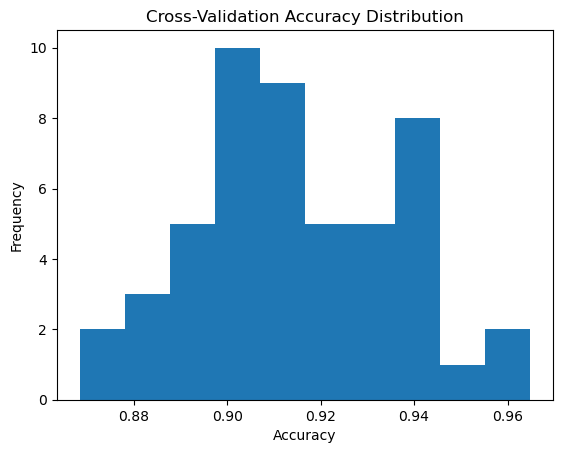

In [ ]:
# (PATH 2b) REPEATED STRATIFIED K-FOLD

# setup repeated stratified k-fold (5x10)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

# run cross-validation
scores = cross_val_score(model, X, y, cv=rskf, scoring='accuracy', n_jobs=-1)

# compute stats
mean_score = scores.mean()
std_score = scores.std()
min_score = scores.min()
max_score = scores.max()

# formatted output
print("Cross-validation Results")
print(f"Runs               : {len(scores)}")
print(f"Mean Accuracy      : {mean_score:.4f}")
print(f"Standard Deviation : {std_score:.4f}")
print(f"Minimum Accuracy   : {min_score:.4f}")
print(f"Maximum Accuracy   : {max_score:.4f}")

# histogram of scores
plt.figure()
plt.hist(scores, bins=10)
plt.title("Cross-Validation Accuracy Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")


Stratified K-Fold Results
Folds              : 5
Mean Accuracy      : 0.9772
Standard Deviation : 0.0163
Minimum Accuracy   : 0.9474
Maximum Accuracy   : 0.9912


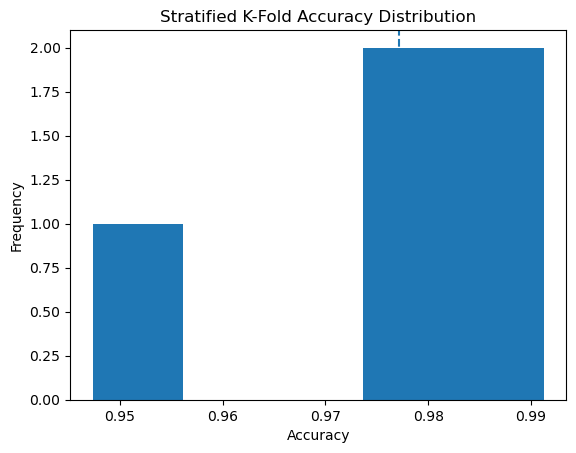

In [ ]:
# (PATH 2c) STRATIFIED K-FOLD

# setup stratified 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc = []

# run cv loop
for train_idx, test_idx in skf.split(X, y):
    # split data
    x_tr, x_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # scale per fold
    x_tr = scaler.fit_transform(x_tr)
    x_te = scaler.transform(x_te)

    # train + predict
    model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    model.fit(x_tr, y_tr)
    y_pred = model.predict(x_te)

    acc.append(accuracy_score(y_te, y_pred))

# compute stats
mean_acc = np.mean(acc)
std_acc = np.std(acc)

# formatted output
print("Stratified K-Fold Results")
print(f"Folds              : {len(acc)}")
print(f"Mean Accuracy      : {mean_acc:.4f}")
print(f"Standard Deviation : {std_acc:.4f}")
print(f"Minimum Accuracy   : {min(acc):.4f}")
print(f"Maximum Accuracy   : {max(acc):.4f}")

plt.figure()
plt.hist(acc, bins=5)
plt.axvline(np.mean(acc), linestyle='dashed')
plt.title("Stratified K-Fold Accuracy Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.show()